In [32]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(1234)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

### Handy utility functions

In [33]:
def append_ones(matrix, axis=1):
    return np.concatenate((matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=axis)

def zeros(*dims):
    return np.zeros(shape=tuple(dims), dtype=np.float32)

def ones(*dims):
    return np.ones(shape=tuple(dims), dtype=np.float32)

def rand(*dims):
    return np.random.rand(*dims).astype(np.float32)

def chunks(seq, size):
    return (seq[pos:pos + size] for pos in range(0, len(seq), size))

def tiles(examples):
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(shape=(rows_count * (tile_height + space_between_tiles) - space_between_tiles,
                                 cols_count * (tile_width + space_between_tiles) - space_between_tiles))
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            ex_min = np.min(examples[r, c])
            ex_max = np.max(examples[r, c])
            img_matrix[x_0:x_0 + tile_height, y_0:y_0 + tile_width] = (examples[r, c] - ex_min) / (ex_max - ex_min)

    plt.matshow(img_matrix, cmap='gray', interpolation='none')
    plt.axis('off')
    plt.show()

# MNIST dataset

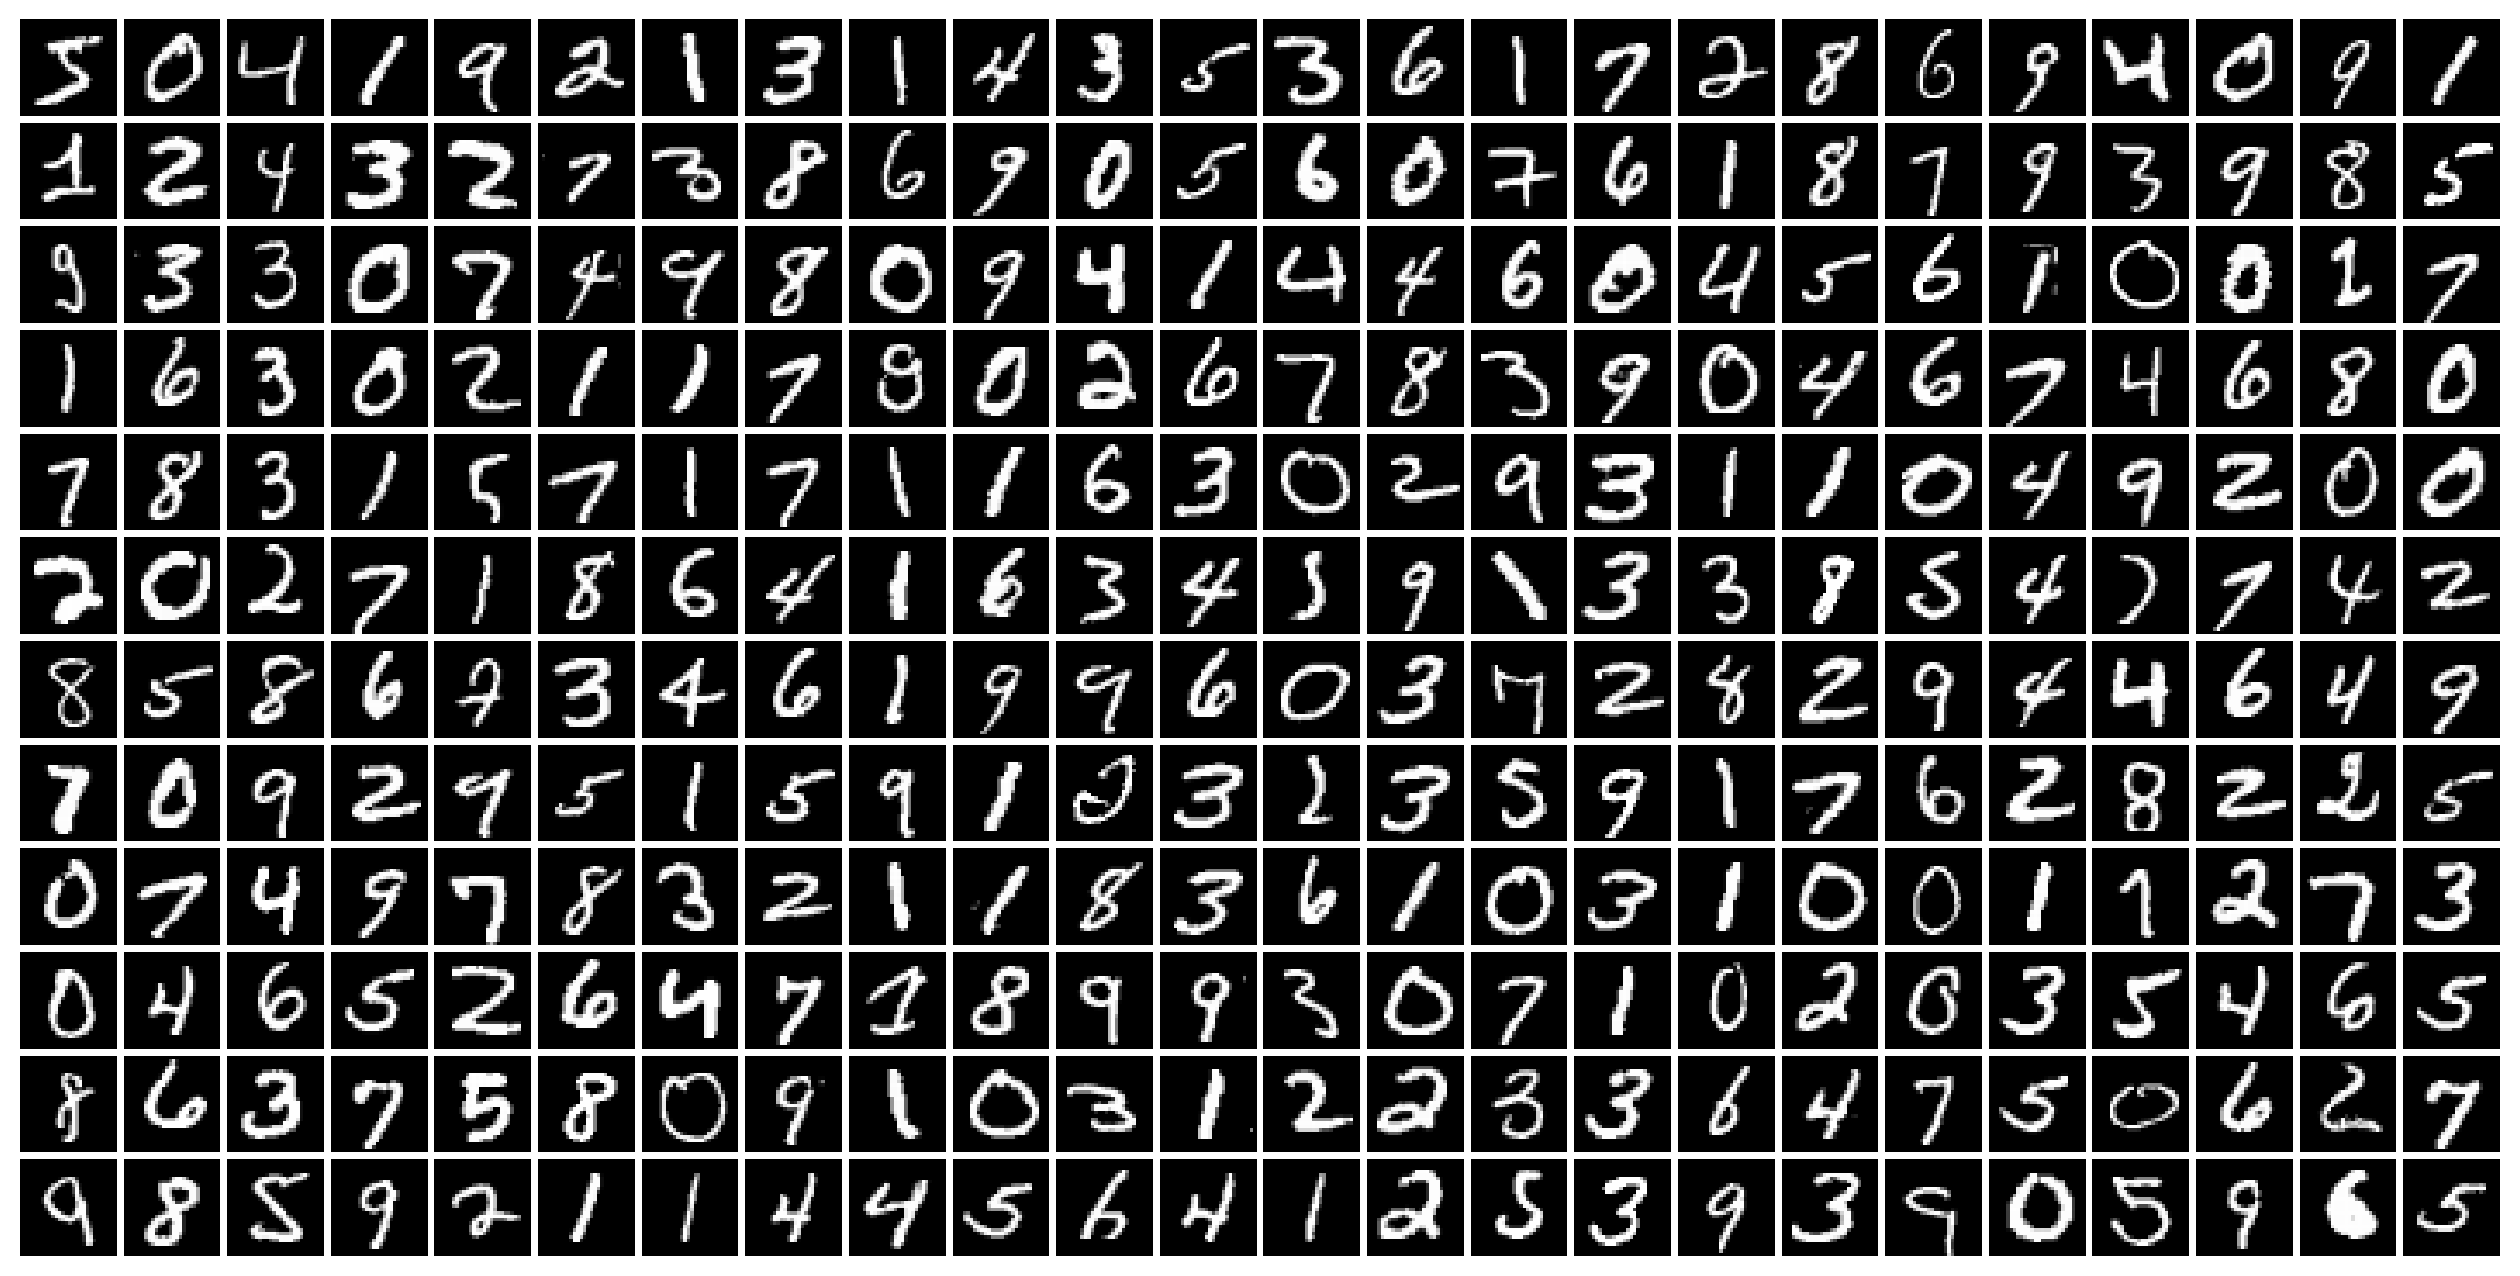

In [34]:
from mnists import MNIST
mnist = MNIST()


def create_mnist_digits() -> np.ndarray:
    n_rows = 12
    n_cols = 24
    tile_dim = 28 # [px]
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[:12*24], newshape=shape)

digits = create_mnist_digits()

tiles(digits)

# Restricted Boltzmann Machine & Contrastive Divergence algorithm

In [35]:
def sigmoid(matrix):
    return 1.0 / (1.0 + np.exp(-matrix))

class Rbm:
    def __init__(self, visible_size, hidden_size, learning_rate, momentum):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.momentum = momentum

        self.reset()

    def reset(self):
        self.W = np.random.normal(scale=0.01, size=(self.visible_size+1, self.hidden_size+1)).astype(np.float32)
        self.W[:, -1] = 0.0
        self.W[-1, :] = 0.0
        self.M = zeros(self.visible_size+1, self.hidden_size+1)

In [36]:
def reconstruction_error(rbm: Rbm, minibatch: np.ndarray) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.

    Runs a single forward-backward pass (encode then decode) without
    weight updates and returns the average squared difference between
    the original visible units and their reconstructions.

    Args:
        rbm:        The trained (or partially trained) RBM.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    with the bias column appended.

    Returns:
        A scalar float: sum of squared errors divided by the number
        of observations.
    """

    observations_count = minibatch.shape[0]
    visible = append_ones(zeros(observations_count, rbm.visible_size))
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    hidden[:, :-1] = sigmoid(minibatch @ rbm.W[:, :-1])
    visible[:, :-1] = sigmoid(hidden @ np.transpose(rbm.W[:-1, :]))
    return np.mean((minibatch[:, :-1] - visible[:, :-1]) ** 2)


In [37]:
# def cdk(rbm: Rbm, minibatch: np.ndarray, k: int = 1) -> None:
#     """
#     Performs a single Contrastive Divergence (CD-k) weight update in-place.

#     CD-k approximates the log-likelihood gradient by running k steps of
#     Gibbs sampling starting from the training data.  The resulting
#     positive and negative phase statistics are used to update rbm.W.

#     All visible and hidden arrays carry an appended bias column (via
#     `append_ones`), so matrix multiplications automatically include biases.

#     Args:
#         rbm:        The RBM whose weights will be updated.
#         minibatch:  A 2D float32 array of shape (n, visible_size + 1),
#                     where the last column is the bias (all ones).
#         k:          Number of Gibbs sampling steps (default 1, i.e. CD-1).
#     """

#     observations_count = minibatch.shape[0]

#     positive_visible = minibatch
#     negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

#     positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
#     negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

#     positive_hidden[:, :-1] = sigmoid(minibatch @ rbm.W[:, :-1])
#     negative_hidden[:, :-1] = (positive_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)

#     for cd_i in range(k):
#         negative_visible[:, :-1] = sigmoid(negative_hidden @ np.transpose(rbm.W[:-1, :]))
#         negative_visible[:, :-1] = (negative_visible[:, :-1] > rand(observations_count, rbm.visible_size)).astype(np.float32)

#         negative_hidden[:, :-1] = sigmoid(negative_visible @ rbm.W[:, :-1])
#         if cd_i < (k - 1):
#             negative_hidden[:, :-1] = (negative_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)
#     #

#     rbm.W += (rbm.learning_rate / observations_count) * (np.transpose(positive_visible) @ positive_hidden)
#     rbm.W -= (rbm.learning_rate / observations_count) * (np.transpose(negative_visible) @ negative_hidden)
# #

# 1. RBM Training with momentum

In [38]:
def cdk(rbm: Rbm, minibatch: np.ndarray, k: int = 1) -> None:
    """
    Performs a single Contrastive Divergence (CD-k) weight update in-place.

    CD-k approximates the log-likelihood gradient by running k steps of
    Gibbs sampling starting from the training data.  The resulting
    positive and negative phase statistics are used to update rbm.W.

    All visible and hidden arrays carry an appended bias column (via
    `append_ones`), so matrix multiplications automatically include biases.

    Args:
        rbm:        The RBM whose weights will be updated.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    where the last column is the bias (all ones).
        k:          Number of Gibbs sampling steps (default 1, i.e. CD-1).
    """

    observations_count = minibatch.shape[0]

    positive_visible = minibatch
    negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

    positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    positive_hidden[:, :-1] = sigmoid(minibatch @ rbm.W[:, :-1])
    negative_hidden[:, :-1] = (positive_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)

    for cd_i in range(k):
        negative_visible[:, :-1] = sigmoid(negative_hidden @ np.transpose(rbm.W[:-1, :]))
        negative_visible[:, :-1] = (negative_visible[:, :-1] > rand(observations_count, rbm.visible_size)).astype(np.float32)

        negative_hidden[:, :-1] = sigmoid(negative_visible @ rbm.W[:, :-1])
        if cd_i < (k - 1):
            negative_hidden[:, :-1] = (negative_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)
    #

    gradient = (np.transpose(positive_visible) @ positive_hidden) - (np.transpose(negative_visible) @ negative_hidden)
    rbm.M = rbm.momentum * rbm.M + (rbm.learning_rate / observations_count) * gradient
    rbm.W += rbm.M
#

In [39]:
def train_epoch(rbm, dataset, batch_size):
    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(rbm, batch)
        if batch_idx % round(batches_limit / 50) == 0: print("#", end="")

def run_training(rbm, dataset, monitoring_set, batch_size, epochs_count):
    for epoch in range(epochs_count):
        print("Epoch {}:".format(epoch),  end="\t")

        if epoch == 5:
            rbm.momentum = 0.8

        start_time = time.time()
        train_epoch(rbm, dataset, batch_size)
        elapsed = time.time() - start_time

        error = reconstruction_error(rbm, monitoring_set)
        print("\telapsed: {0:>2.2f}s, reconstruction error: {1:>2.2f}".format(elapsed, error))

    print("Training finished!")

def draw_filters(rbm):
    filters = np.reshape(np.transpose(rbm.W)[:-1, :-1], newshape=(8, -1, 28, 28))
    tiles(filters)

In [40]:
import time

DATASET_SIZE = 20000 # 60000 for whole dataset
DIGIT_SIZE = 28

VISIBLE_LAYER_SIZE = DIGIT_SIZE*DIGIT_SIZE
HIDDEN_LAYER_SIZE = 128

mnist_train = mnist.train_images().astype(np.float32) / 255.0
np.random.shuffle(mnist_train)
dataset = np.reshape(mnist_train[:DATASET_SIZE], newshape=(DATASET_SIZE, DIGIT_SIZE*DIGIT_SIZE))
dataset = append_ones(dataset)

monitoring_indeces = np.random.choice(DATASET_SIZE, 256, replace=False)
monitoring_set = dataset[monitoring_indeces]

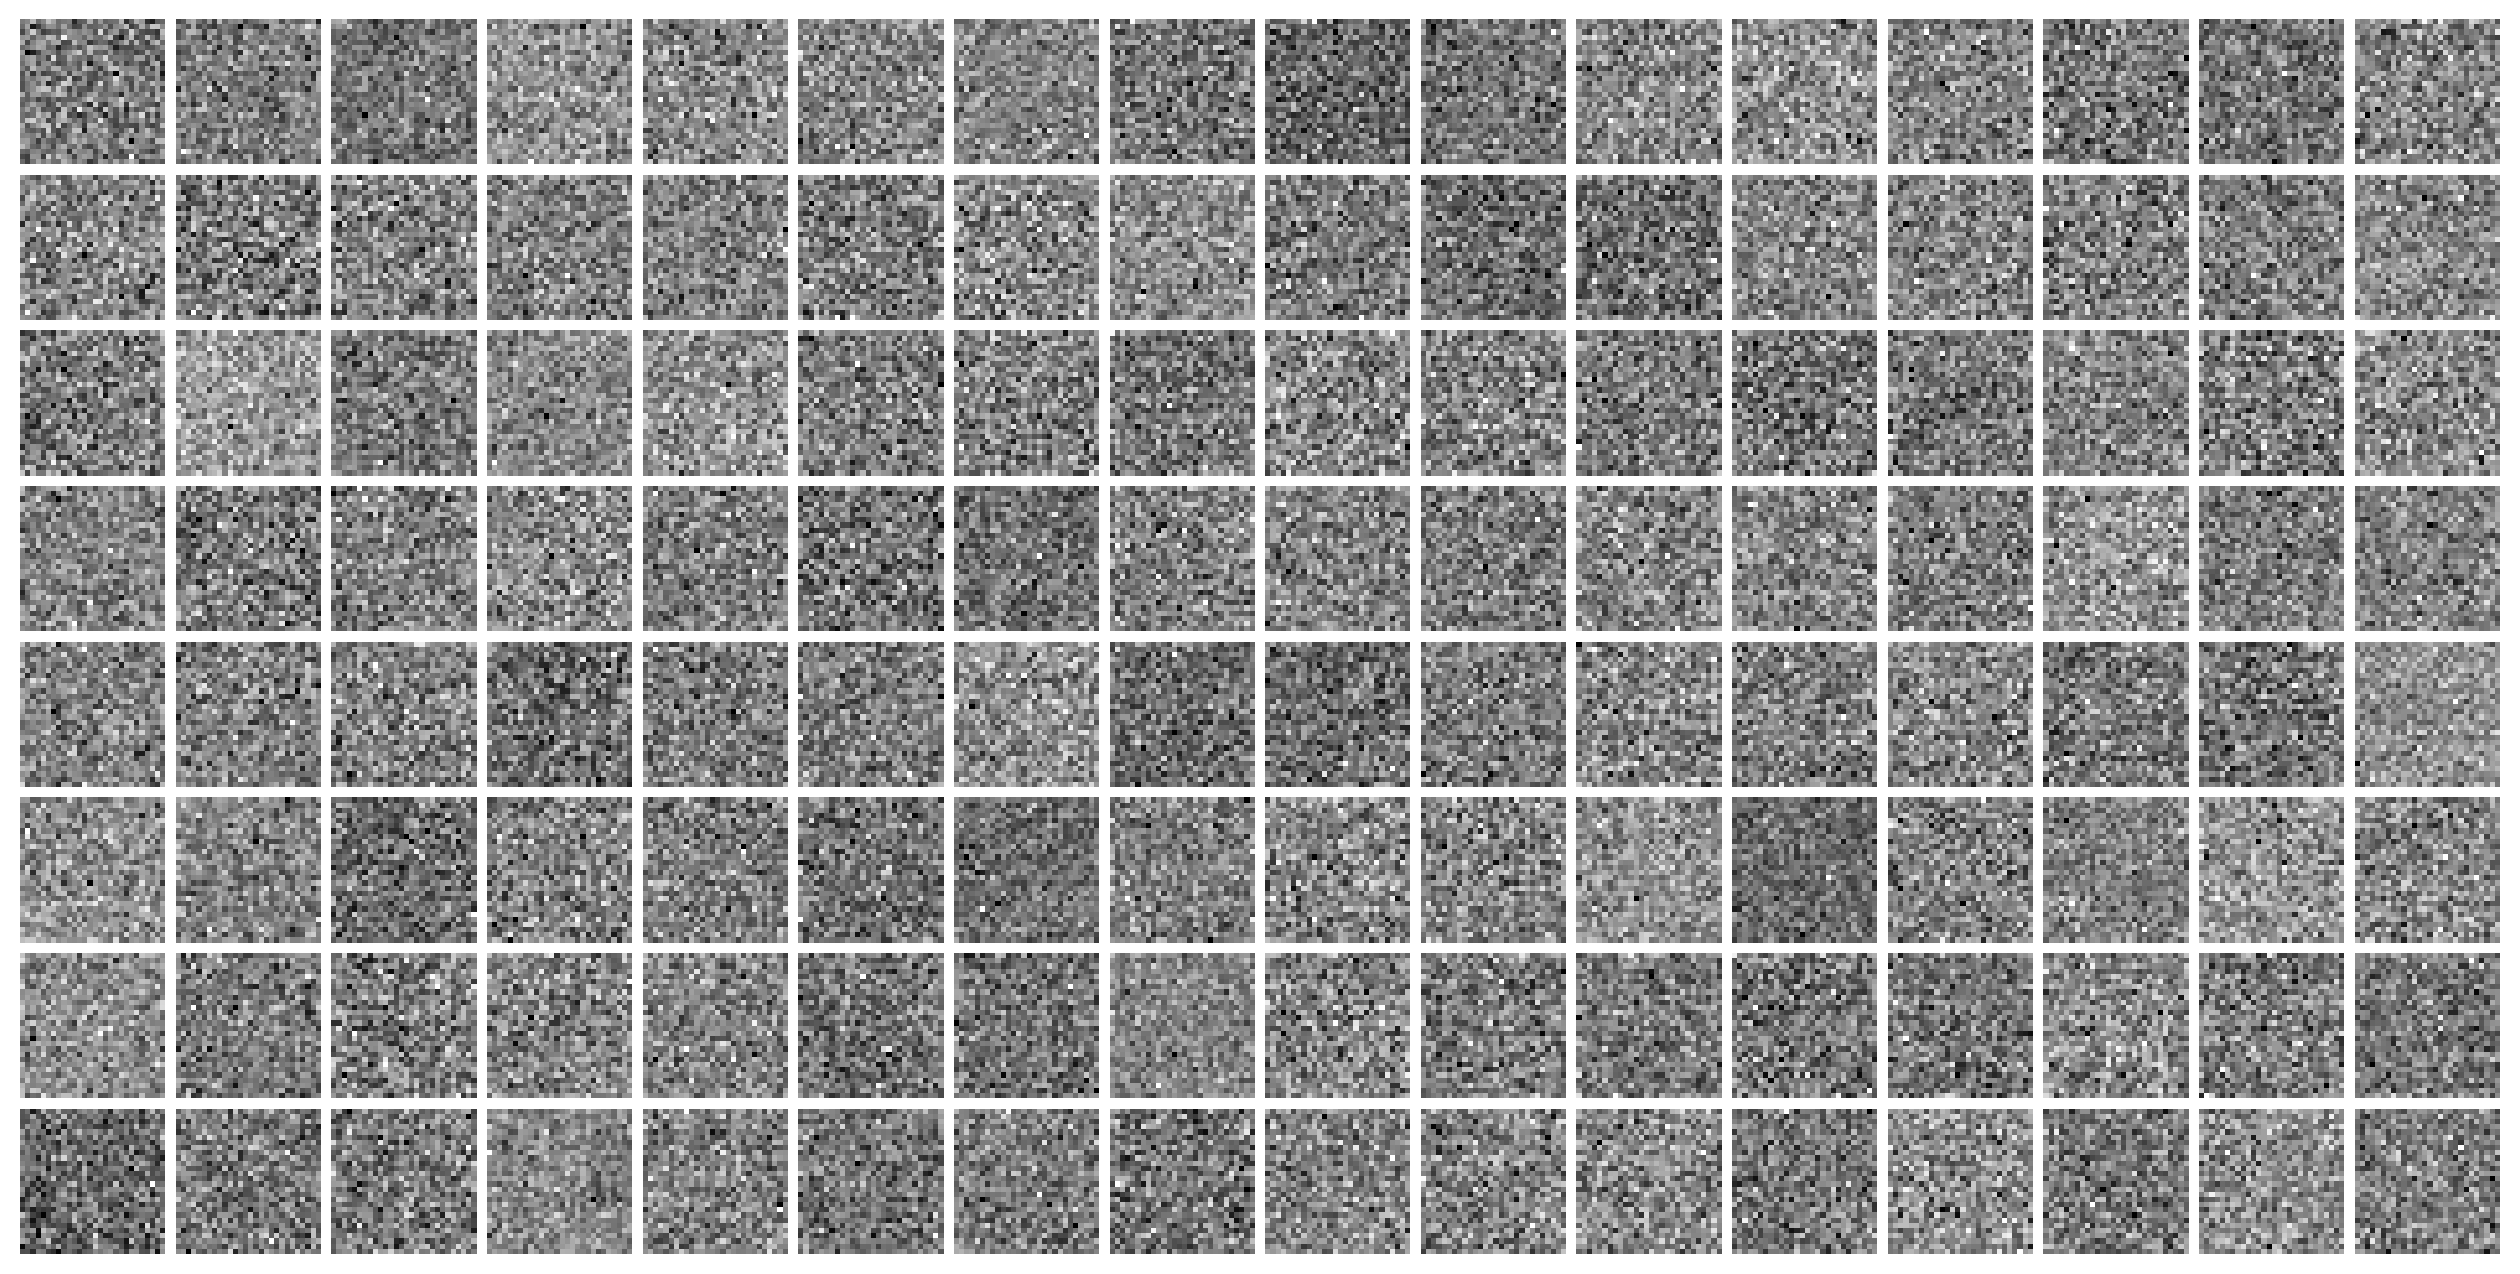

Epoch 0:	#####################################################	elapsed: 0.58s, reconstruction error: 0.03
Epoch 1:	#####################################################	elapsed: 0.47s, reconstruction error: 0.02
Epoch 2:	#####################################################	elapsed: 0.48s, reconstruction error: 0.02
Epoch 3:	#####################################################	elapsed: 0.48s, reconstruction error: 0.02
Epoch 4:	#####################################################	elapsed: 0.50s, reconstruction error: 0.02
Epoch 5:	#####################################################	elapsed: 0.44s, reconstruction error: 0.02
Epoch 6:	#####################################################	elapsed: 0.50s, reconstruction error: 0.01
Epoch 7:	#####################################################	elapsed: 0.50s, reconstruction error: 0.01
Epoch 8:	#####################################################	elapsed: 0.49s, reconstruction error: 0.01
Epoch 9:	#####################################

C:\Users\Filip\AppData\Local\Temp\ipykernel_11196\2338486560.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-matrix))


######################	elapsed: 0.49s, reconstruction error: 0.01
Epoch 43:	#####################################################	elapsed: 0.51s, reconstruction error: 0.01
Epoch 44:	#####################################################	elapsed: 0.56s, reconstruction error: 0.01
Epoch 45:	#####################################################	elapsed: 0.48s, reconstruction error: 0.01
Epoch 46:	#####################################################	elapsed: 0.48s, reconstruction error: 0.01
Epoch 47:	#####################################################	elapsed: 0.56s, reconstruction error: 0.01
Epoch 48:	#####################################################	elapsed: 0.49s, reconstruction error: 0.01
Epoch 49:	#####################################################	elapsed: 0.53s, reconstruction error: 0.01
Training finished!


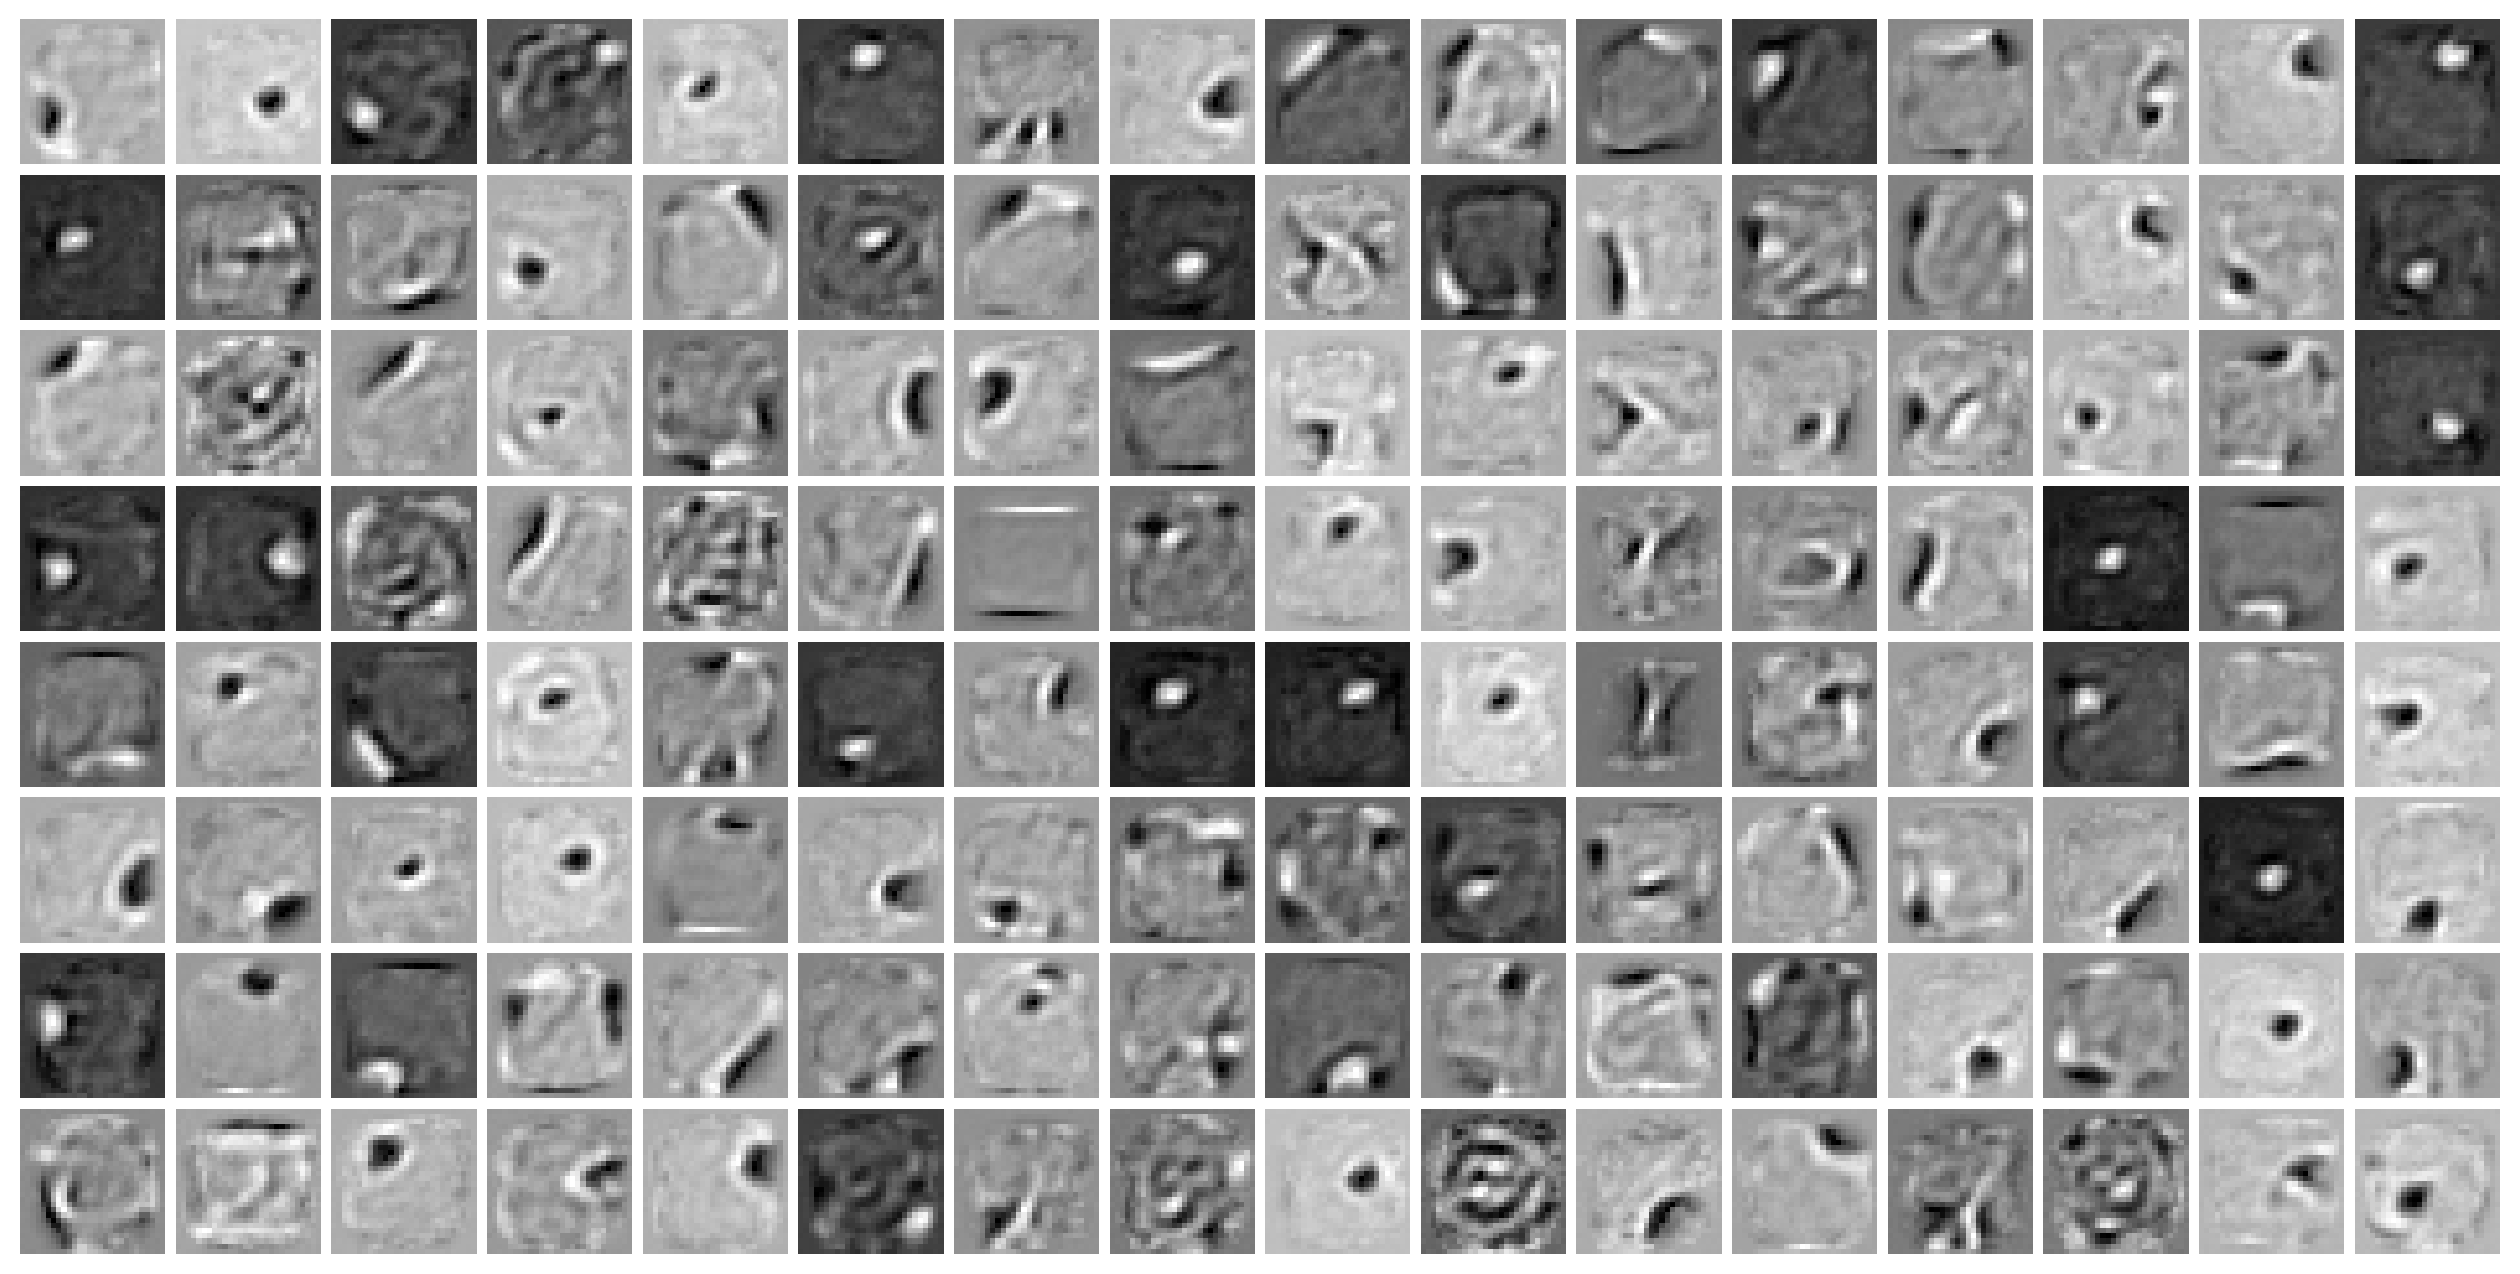

In [41]:
BATCH_SIZE = 128
EPOCHS_COUNT = 50

LEARNING_RATE = 0.1
MOMENTUM = 0.5

rbm = Rbm(VISIBLE_LAYER_SIZE, HIDDEN_LAYER_SIZE, LEARNING_RATE, MOMENTUM)
draw_filters(rbm)

run_training(rbm, dataset, monitoring_set, BATCH_SIZE, EPOCHS_COUNT)

draw_filters(rbm)

# 2. DBN Training

In [42]:
def propagate_up(dbn, layers_count, visible):
    for i in range(layers_count):
        visible = append_ones(sigmoid(visible @ dbn[i].W[:, :-1]))
    return visible

def propagate_down(dbn, layers_count, hidden):
    for i in reversed(range(layers_count)):
        hidden = append_ones(sigmoid(hidden @ np.transpose(dbn[i].W[:-1, :])))
    return hidden

### DBN reconstruction error

In [43]:
def dbn_reconstuction_error(dbn, layers_count, minibatch):
    hidden = propagate_up(dbn, layers_count, minibatch)
    visible = propagate_down(dbn, layers_count, hidden)
    return np.mean((minibatch[:, :-1] - visible[:, :-1]) ** 2)

### Sampling in Deep Belief Networks

In [44]:
def sample_rbm(rbm, minibatch, steps):
    observations_count = minibatch.shape[0]

    visible = minibatch
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    for cd_i in range(steps):
        hidden[:, :-1] = sigmoid(visible @ rbm.W[:, :-1])
        hidden[:, :-1] = (hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)

        visible[:, :-1] = sigmoid(hidden @ np.transpose(rbm.W[:-1, :]))
        if cd_i < (steps - 1):
            visible[:, :-1] = (visible[:, :-1] > rand(observations_count, rbm.visible_size)).astype(np.float32)

    return visible

In [45]:
def sample_dbn(dbn, layer_idx, minibatch, steps):
    observations_count = minibatch.shape[0]

    visible = propagate_up(dbn, layer_idx, minibatch)
    hidden = append_ones(zeros(observations_count, dbn[layer_idx].hidden_size))

    for cd_i in range(steps):
        hidden[:, :-1] = sigmoid(visible @ dbn[layer_idx].W[:, :-1])
        hidden[:, :-1] = (hidden[:, :-1] > rand(observations_count, dbn[layer_idx].hidden_size)).astype(np.float32)

        visible[:, :-1] = sigmoid(hidden @ np.transpose(dbn[layer_idx].W[:-1, :]))
        if cd_i < (steps - 1):
            visible[:, :-1] = (visible[:, :-1] > rand(observations_count, dbn[layer_idx].visible_size)).astype(np.float32)

    return propagate_down(dbn, layer_idx, visible)

In [46]:
def draw_layer_samples(dbn, layer_idx, minibatch, steps=200):
    samples = sample_dbn(dbn, layer_idx, minibatch, steps)
    tiles(np.reshape(samples[:, :-1], newshape=(-1, 16, 28, 28)))

### Greedy layer-wise training

In [47]:
def train_dbn(dbn, layer_idx, dataset, batch_size):
    dataset = propagate_up(dbn, layer_idx, dataset)

    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(dbn[layer_idx], batch)
        if batch_idx % round(batches_limit / 50) == 0: print("#", end="")

In [48]:
BATCH_SIZE = 128
EPOCHS_COUNT = 50

LEARNING_RATE = 0.1
MOMENTUM = 0.5

DBN_HIDDEN_LAYER_SIZE = 200
dbn = [
    Rbm(VISIBLE_LAYER_SIZE, DBN_HIDDEN_LAYER_SIZE, LEARNING_RATE, MOMENTUM),
    Rbm(DBN_HIDDEN_LAYER_SIZE, DBN_HIDDEN_LAYER_SIZE, LEARNING_RATE, MOMENTUM),
    Rbm(DBN_HIDDEN_LAYER_SIZE, DBN_HIDDEN_LAYER_SIZE, LEARNING_RATE, MOMENTUM)
]

for layer_idx in range(len(dbn)):
    print("\nLearning layer {}".format(layer_idx))

    for epoch in range(EPOCHS_COUNT):
        print("Epoch {}:".format(epoch),  end="\t")

        if epoch == 5:
            dbn[layer_idx].momentum = 0.8
        
        start_time = time.time()
        train_dbn(dbn, layer_idx, dataset, BATCH_SIZE)
        elapsed = time.time() - start_time
        
        error = dbn_reconstuction_error(dbn, layer_idx, monitoring_set)
        print("\telapsed: {0:>2.2f}s, reconstruction error: {1:>2.2f}".format(elapsed, error))
    
print("Training finished!")


Learning layer 0
Epoch 0:	#####################################################	elapsed: 0.76s, reconstruction error: 0.00
Epoch 1:	#####################################################	elapsed: 0.65s, reconstruction error: 0.00
Epoch 2:	#####################################################	elapsed: 0.65s, reconstruction error: 0.00
Epoch 3:	#####################################################	elapsed: 0.64s, reconstruction error: 0.00
Epoch 4:	#####################################################	elapsed: 0.66s, reconstruction error: 0.00
Epoch 5:	#####################################################	elapsed: 0.64s, reconstruction error: 0.00
Epoch 6:	#####################################################	elapsed: 0.66s, reconstruction error: 0.00
Epoch 7:	#####################################################	elapsed: 0.64s, reconstruction error: 0.00
Epoch 8:	#####################################################	elapsed: 0.68s, reconstruction error: 0.00
Epoch 9:	###################

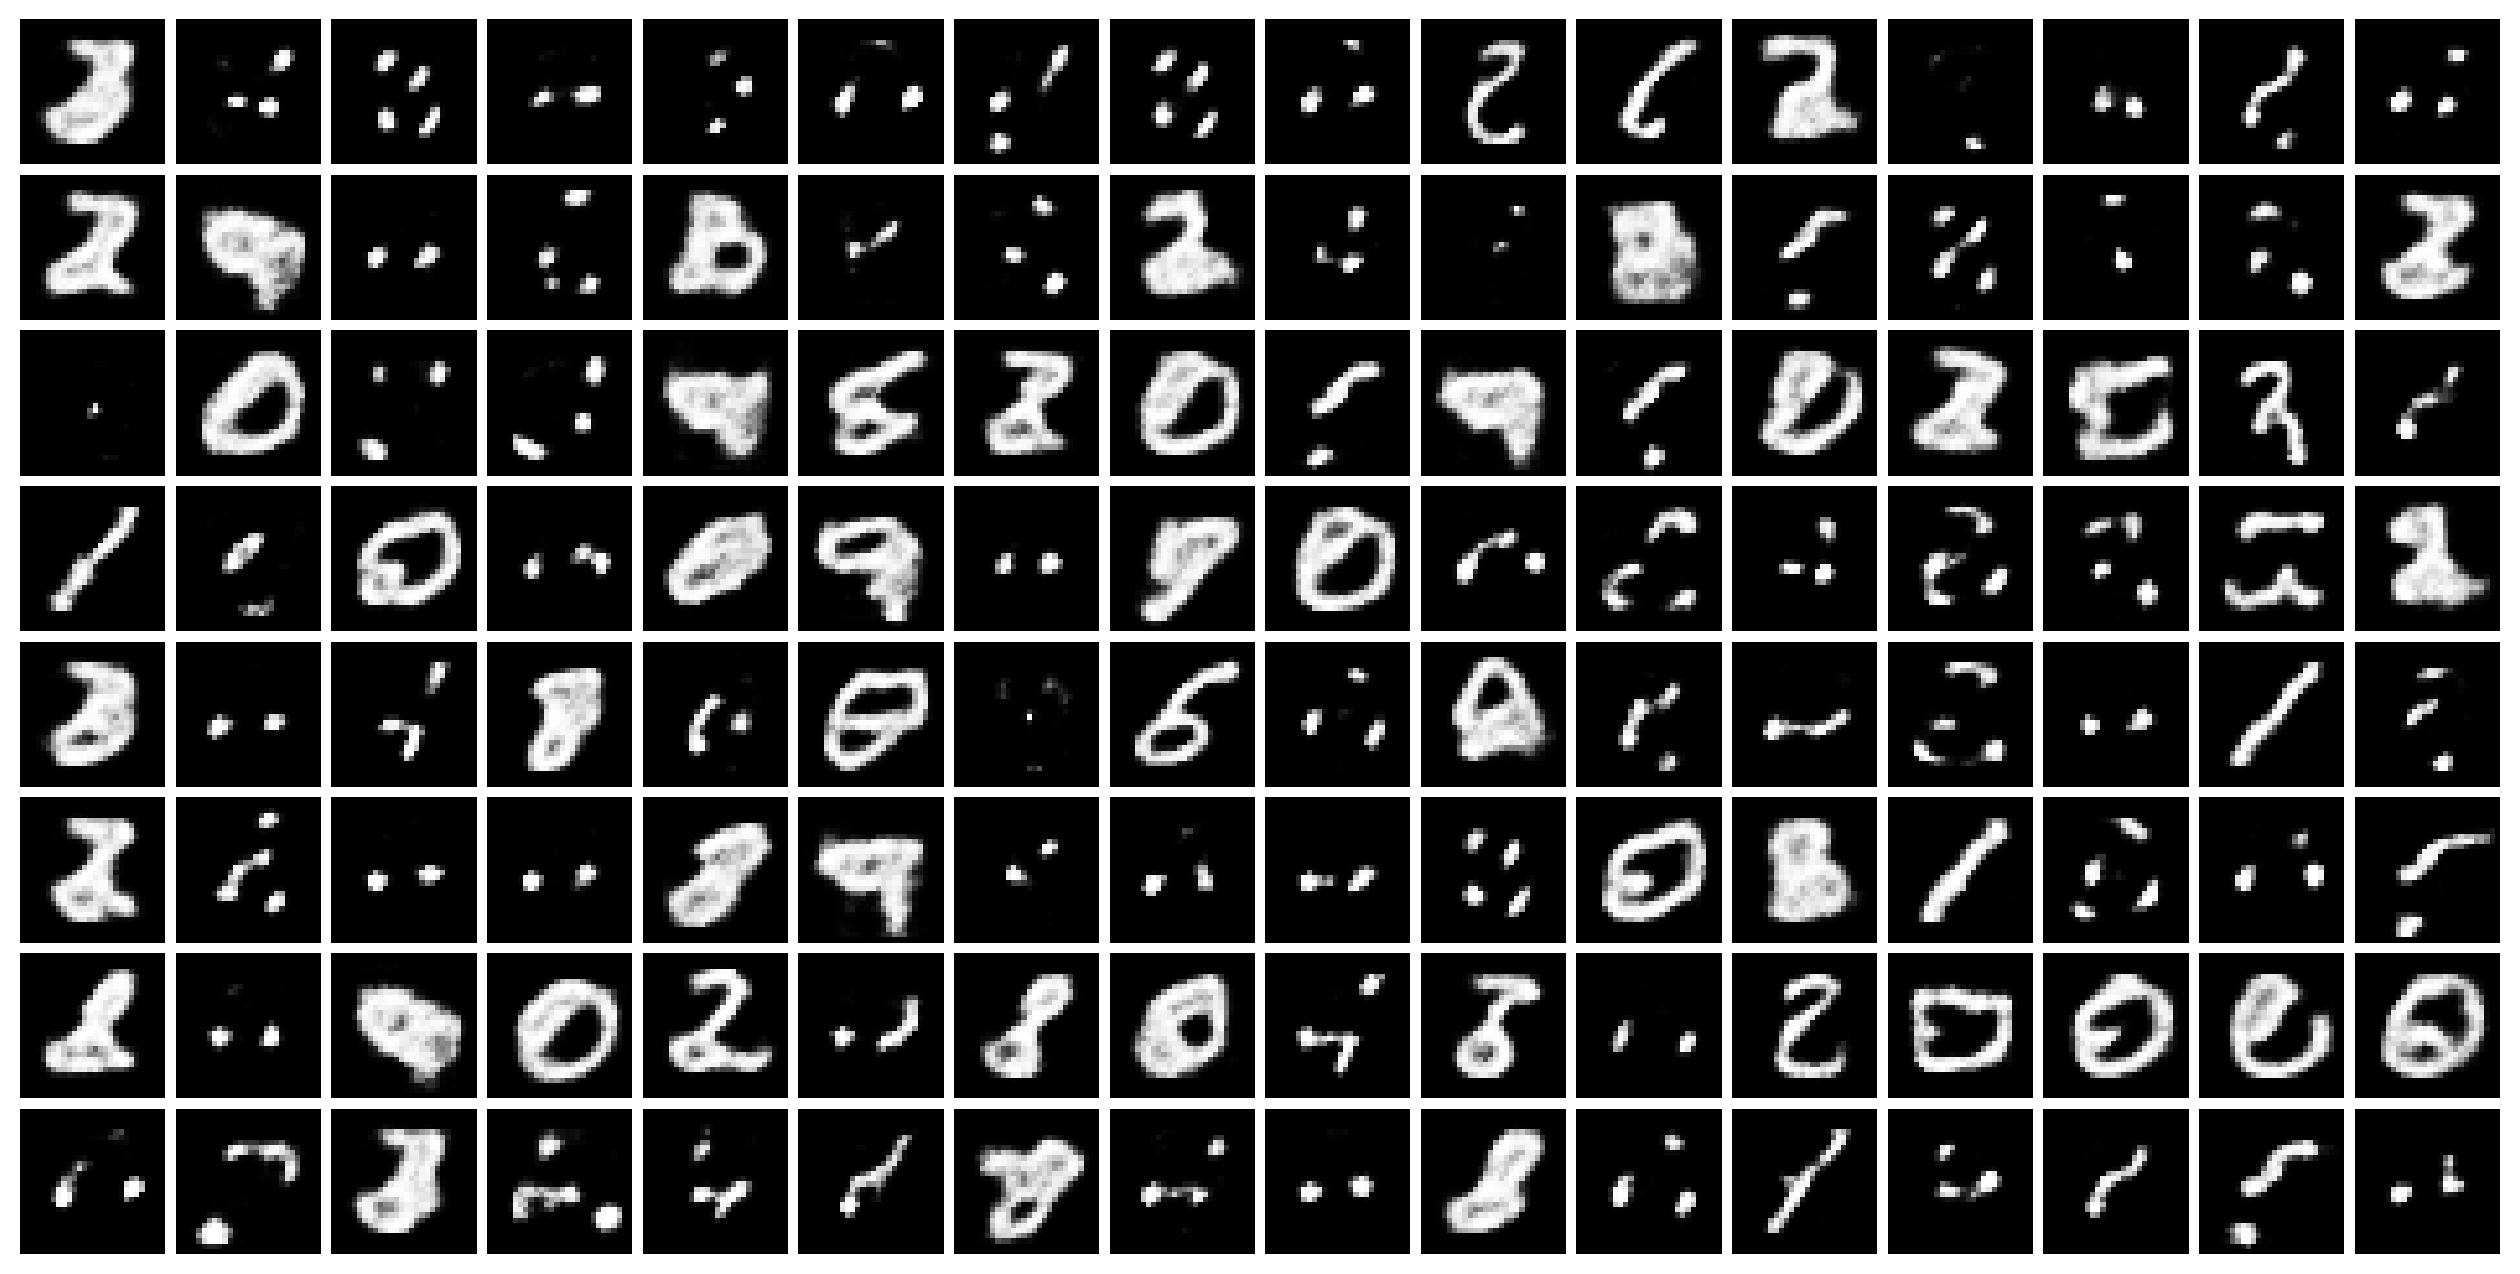

In [49]:
draw_layer_samples(dbn, 0, monitoring_set[:8*16])

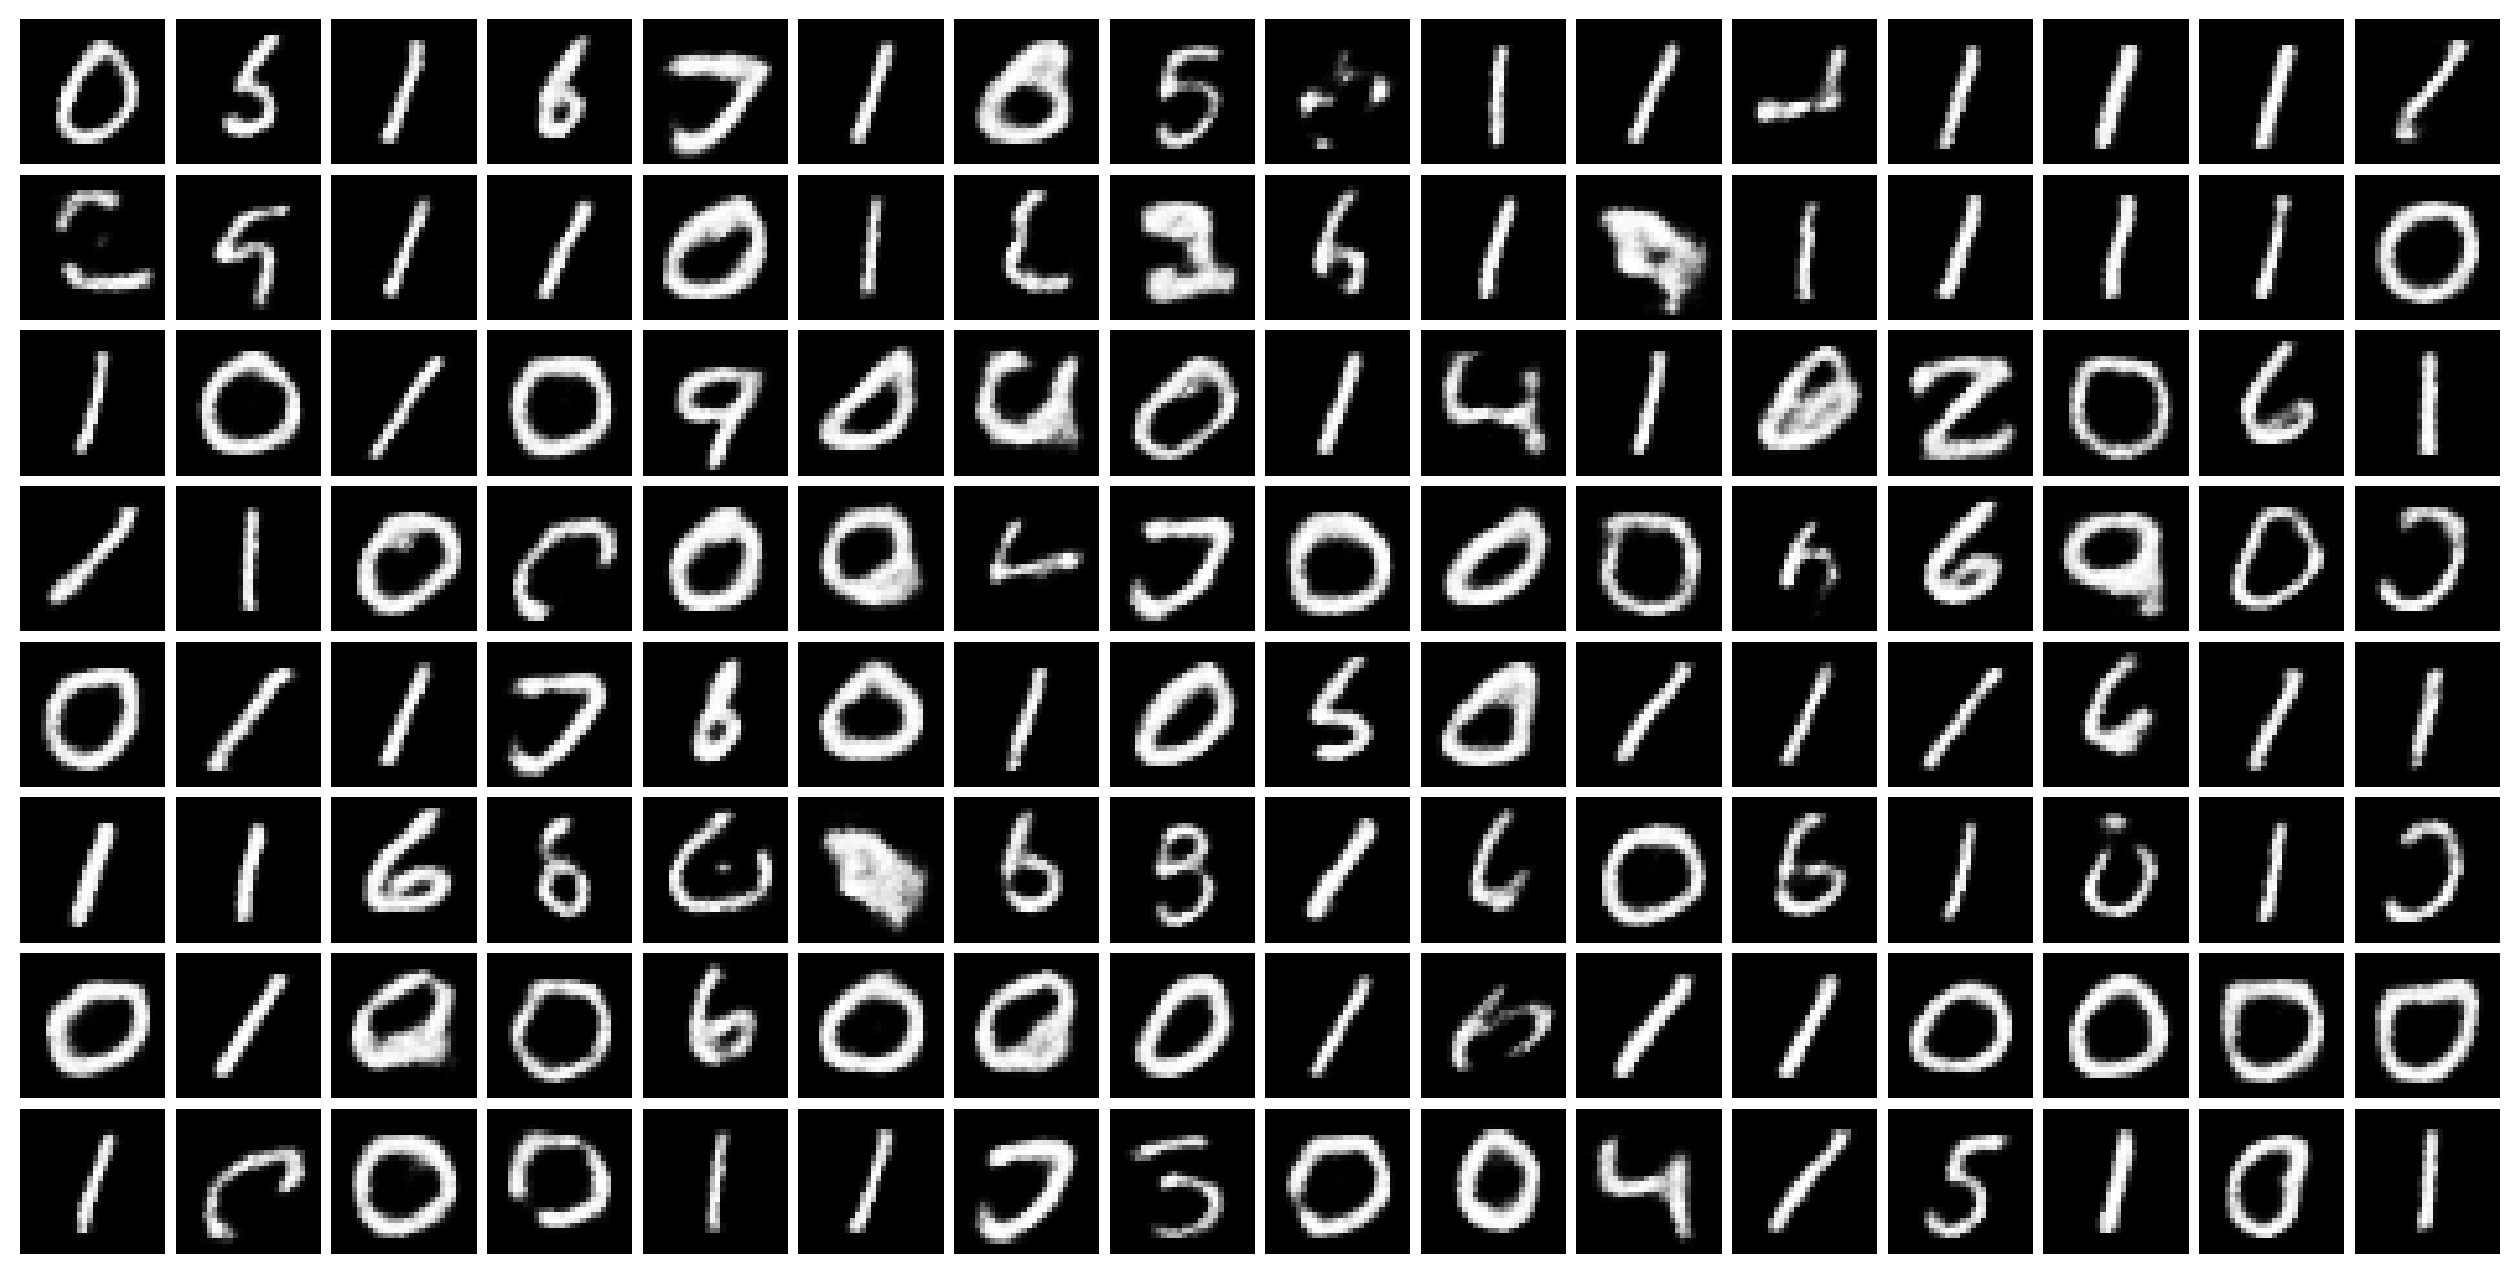

In [50]:
draw_layer_samples(dbn, 1, monitoring_set[:8*16])

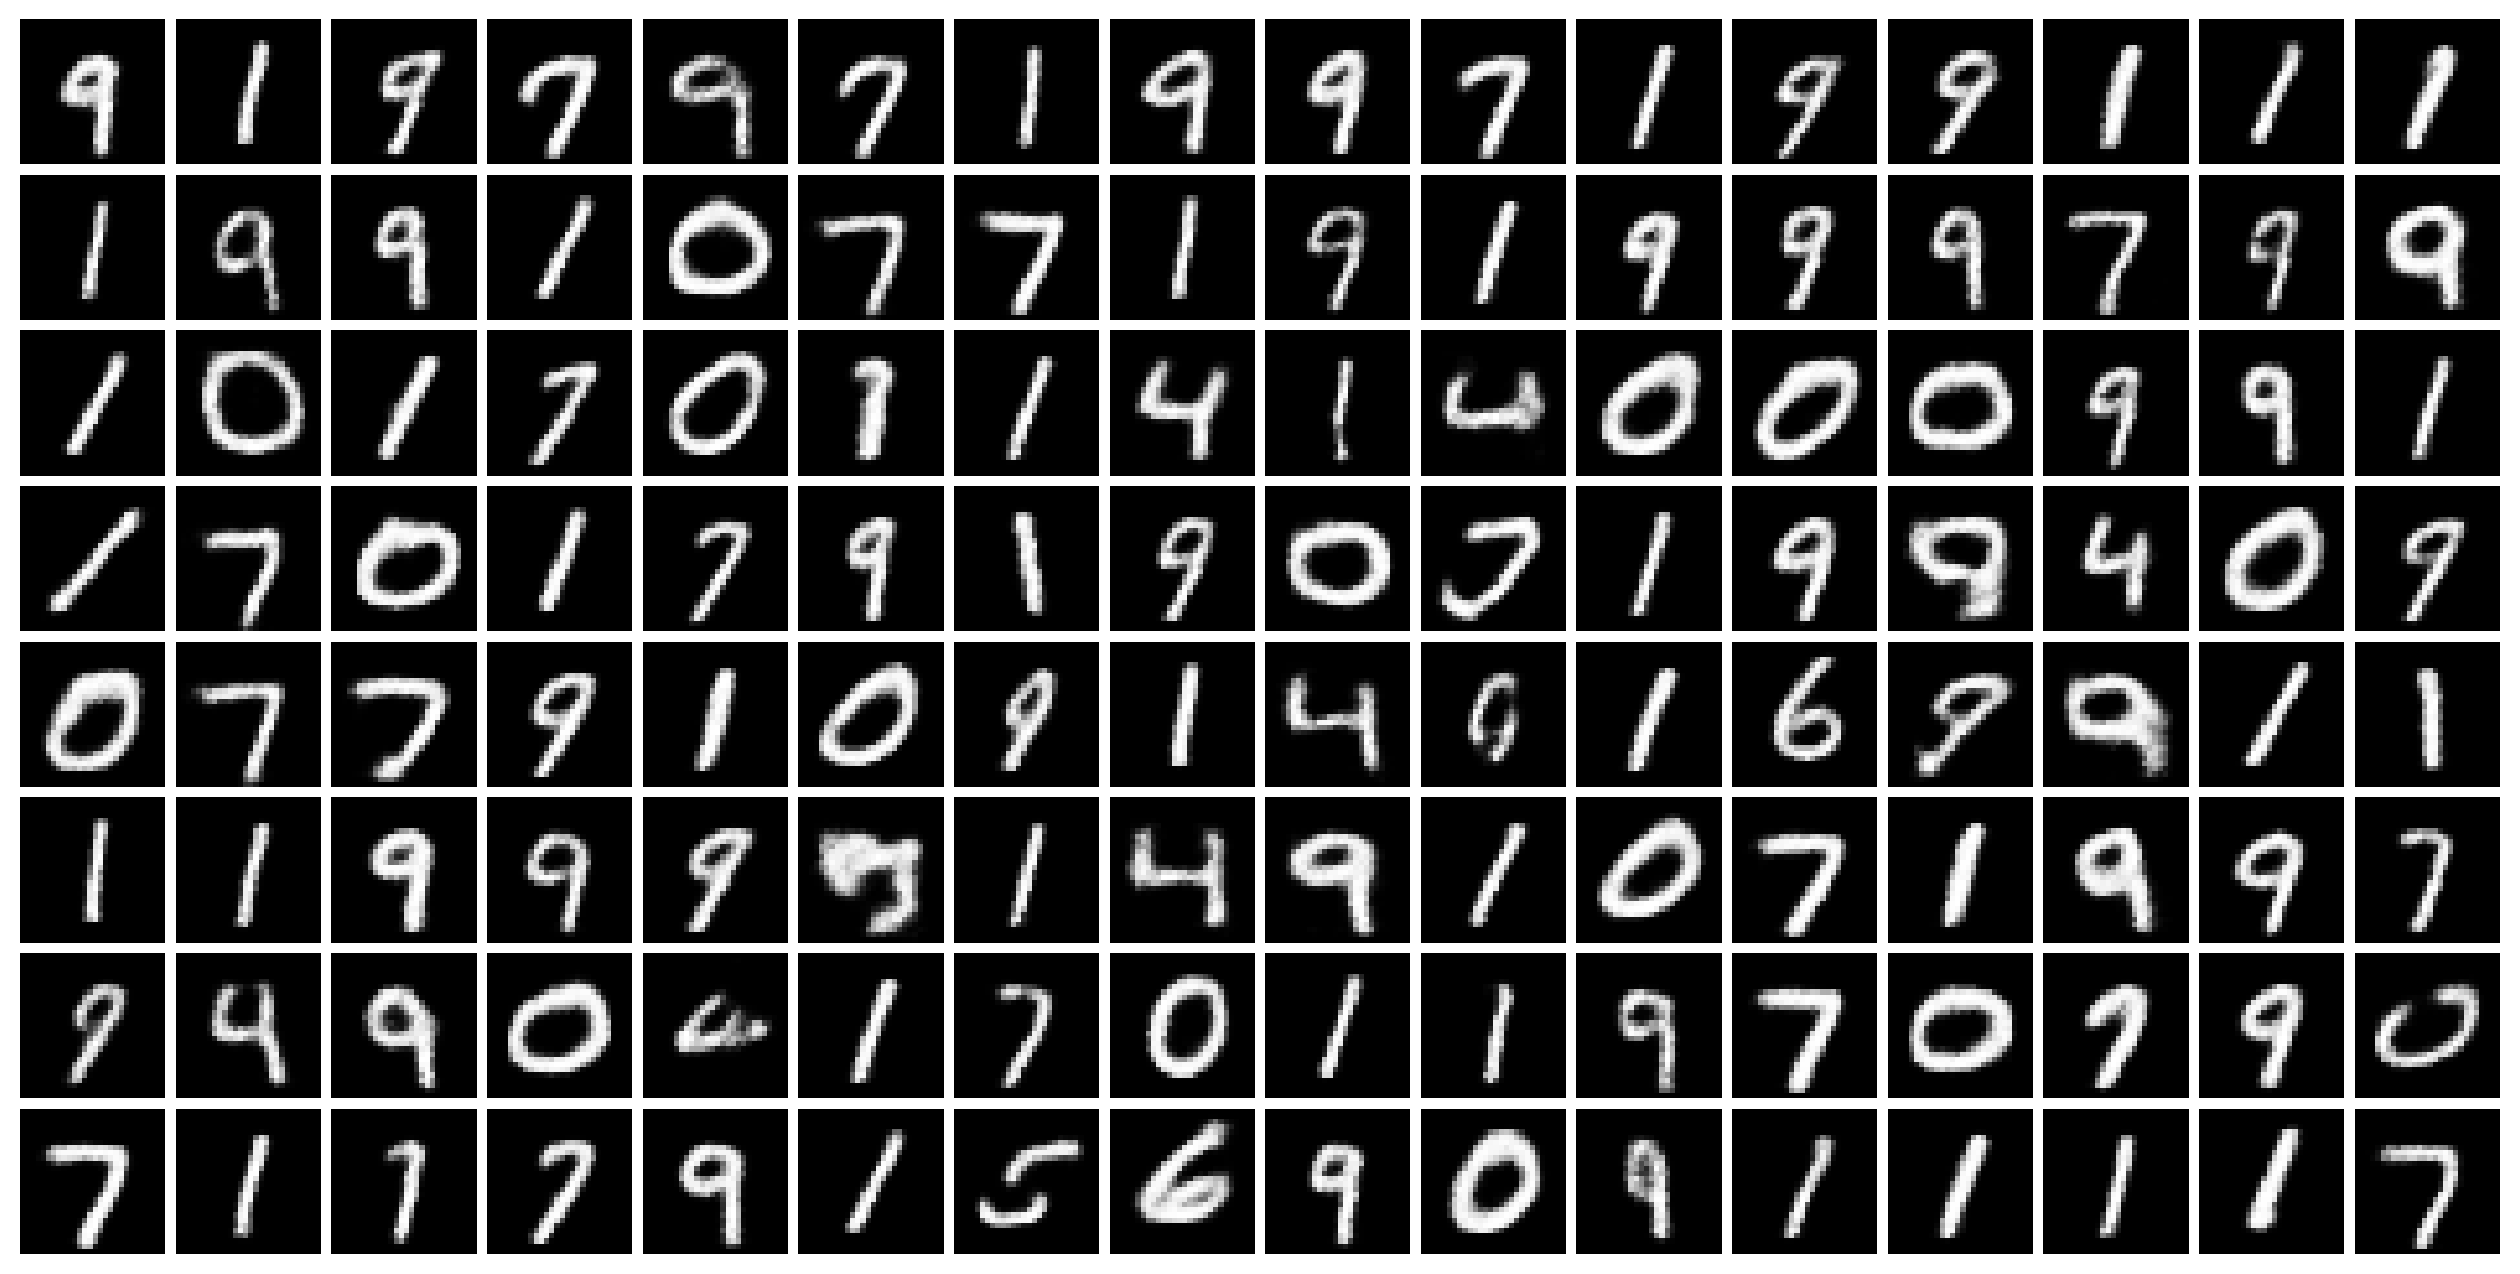

In [51]:
draw_layer_samples(dbn, 2, monitoring_set[:8*16])